# Temporal Fire Hotspot Detection — Biobío Region, January 2026

## Scientific Motivation

The NOₓ EMG pipeline (Jin et al. 2021) requires a **fire centre** as the coordinate
origin for wind-frame rotation and emission integration. The quality of the emission
estimate is directly sensitive to errors in fire centre placement: a 20 km offset
displaces the rotated plume cross-section, shifts the background window, and biases
the fitted EMG parameters.

This notebook implements the fire centre identification methodology from Jin et al. (2021):

1. **MODIS MCD14DL active fire detections** — Aqua instrument, daytime only,
   confidence ≥ 75, co-temporal with TROPOMI overpass.
3. **20 km single-linkage hierarchical clustering** — merges individual 1 km × 1 km
   fire pixels into coherent source clusters. The 20 km threshold corresponds to the
   typical size of an actively burning fire complex in temperate forests.
4. **Dominant cluster selection** — within 300 km of Concepción (−36.83°N, −73.05°E),
   cluster with highest averaged FRP and FRP ≥ 200 MW selected.
5. **TROPOMI AER_AI overlay** — OFFL L2 swath (aerosol_index_354_388) confirms that
   the selected cluster is driving the elevated aerosol signal measured by TROPOMI.

The 18-day window (Jan 7–25) spans the transition from isolated fires to the major
Jan 18–22 outbreak. Tracking day-by-day cluster evolution motivates why Jan 18 is
the primary case study throughout the pipeline notebooks.

**Output products:**
- Per-day scene figures: `figures/temporal_hotspot/{MMDD}.png`
- Animated GIF: `figures/temporal_hotspot/aerosol_fire_evolution.gif`
- Daily dominant cluster CSV: `data/daily_dominant_hotspot_summary.csv`

In [1]:
%cd ..

/Users/maperezc/Downloads/wildfires


In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Optional

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import json

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

PROJECT_ROOT = Path(".").resolve()
DATA_ROOT    = PROJECT_ROOT / "data"
MODIS_CSV    = DATA_ROOT / "fire_nrt_M-C61_723973.csv"

FIGURES_DIR  = PROJECT_ROOT / "outputs" / "temporal_hotspot"
OUTPUT_CSV      = DATA_ROOT / "daily_dominant_hotspot_summary.csv"
OUTPUT_LONG_CSV = DATA_ROOT / "daily_significant_clusters.csv"
OUTPUT_GIF   = FIGURES_DIR / "aerosol_fire_evolution.gif"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Study window
# ---------------------------------------------------------------------------

DATE_START = pd.Timestamp("2026-01-16")
DATE_END   = pd.Timestamp("2026-01-22")

# ---------------------------------------------------------------------------
# Domain bounding box — matches ALL TROPOMI scripts exactly (CLAUDE.md)
# ---------------------------------------------------------------------------

LAT_MIN: float = -66.83
LAT_MAX: float =  -6.83
LON_MIN: float = -103.05
LON_MAX: float =  -43.05

In [3]:
# ---------------------------------------------------------------------------
# Plot domain — zoomed to Biobío / central Chile
# ---------------------------------------------------------------------------
PLOT_LAT_MIN: float = -42.0
PLOT_LAT_MAX: float = -32.0
PLOT_LON_MIN: float = -78.0
PLOT_LON_MAX: float = -68.0

# AER_AI crop (slightly larger than plot domain to avoid edge effects)
AER_LAT_MIN: float = -47.0
AER_LAT_MAX: float = -26.0
AER_LON_MIN: float = -82.0
AER_LON_MAX: float = -62.0

# ---------------------------------------------------------------------------
# Analysis constants
# ---------------------------------------------------------------------------

CONCEPCION_LAT: float  = -36.83   # fire-season reference point
CONCEPCION_LON: float  = -73.05

CLUSTER_RADIUS_KM: float     = 20.0   # Jin et al. (2021) single-linkage threshold
DOMINANT_SEARCH_KM: float    = 300.0  # max distance from Concepción for dominant cluster
MIN_FRP_MW: float            = 100.0  # minimum total cluster FRP for pipeline inclusion
# MIN_FRP_MW: validity gate — dominant cluster must meet it for a day to be flagged valid.
# SIGNIFICANT_FRP_THRESHOLD_MW: display gate — all clusters at or above this are
# retained in plots and CSVs regardless of whether they become the dominant cluster.
# Set equal to MIN_FRP_MW to use a single threshold for both purposes.
SIGNIFICANT_FRP_THRESHOLD_MW: float = MIN_FRP_MW  # MW
FRP_MARKER_SCALE: float = 100.0  # significant-cluster circle size: scale × log1p(frp/100)

MIN_CONFIDENCE: int          = 75     # MODIS MCD14DL confidence threshold
DAYTIME_ONLY: bool           = True   # exclude nighttime detections

QA_THRESH: float             = 0.5   # NOₓ pipeline QA (retains smoke-affected pixels)
TROPOMI_FILL: float          = 9.96921e+36  # NOT caught by np.isfinite()
EARTH_RADIUS_KM = 6371.0

print("Constants loaded.")
print(f"Study window: {DATE_START.date()} → {DATE_END.date()} ({(DATE_END - DATE_START).days + 1} days)")
print(f"Figures dir:  {FIGURES_DIR}")

Constants loaded.
Study window: 2026-01-16 → 2026-01-22 (7 days)
Figures dir:  /Users/maperezc/Downloads/wildfires/outputs/temporal_hotspot


## Data Sources

| Source | File | What we use |
|--------|------|-------------|
| MODIS MCD14DL | `data/fire_nrt_M-C61_723973.csv` | Fire pixel lat/lon/FRP/confidence/time |
| TROPOMI AER_AI | `data/{MMDD}/S5P_OFFL_L2__AER_AI_*.nc` | `aerosol_index_354_388`, `qa_value` |

### HDF5 key paths (AER_AI L2)

```
PRODUCT/aerosol_index_354_388  : (1, nscan, 450) float32 — UV Aerosol Index
PRODUCT/qa_value               : (1, nscan, 450) uint8   — divide by 100 → float [0,1]
PRODUCT/latitude               : (1, nscan, 450) float32
PRODUCT/longitude              : (1, nscan, 450) float32
```

**Fill value warning:** `TROPOMI_FILL = 9.96921e+36`. This is below `float32` maximum
(3.4×10³⁸), so `np.isfinite()` returns `True` for fill pixels. Always check
`data >= TROPOMI_FILL` before analysis.

In [4]:
# ---------------------------------------------------------------------------
# Load and filter MODIS MCD14DL CSV
# ---------------------------------------------------------------------------

df_raw = pd.read_csv(
    MODIS_CSV,
    parse_dates=["acq_date"],
    dtype={"acq_time": str, "confidence": int, "version": str},
)

# Verify schema
EXPECTED_COLS = [
    "latitude", "longitude", "brightness", "scan", "track",
    "acq_date", "acq_time", "satellite", "instrument",
    "confidence", "version", "bright_t31", "frp", "daynight",
]
missing = [c for c in EXPECTED_COLS if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing expected MCD14DL columns: {missing}")

# Apply all four filters (must match modis_frp_eda.ipynb exactly)
df = df_raw.copy()
df = df[(df["acq_date"] >= DATE_START) & (df["acq_date"] <= DATE_END)]
df = df[
    (df["latitude"]  >= LAT_MIN) & (df["latitude"]  <= LAT_MAX)
    & (df["longitude"] >= LON_MIN) & (df["longitude"] <= LON_MAX)
]
df = df[df["confidence"] >= MIN_CONFIDENCE]
if DAYTIME_ONLY:
    df = df[df["daynight"] == "D"]

# Select only Aqua to match TROPOMI overpass
df = df[df['satellite']== 'Aqua']

# Build datetime_utc from date + HHMM string
df = df.copy()
df["acq_time"] = df["acq_time"].astype(str).str.zfill(4)
df["datetime_utc"] = pd.to_datetime(
    df["acq_date"].dt.strftime("%Y-%m-%d")
    + " "
    + df["acq_time"].str[:2] + ":" + df["acq_time"].str[2:],
    format="%Y-%m-%d %H:%M",
)
df = df.reset_index(drop=True)

print("MODIS detections (Jan 14–22 study window):")
print(f"  Total filtered rows: {len(df):,}")
print(f"  FRP range: {df['frp'].min():.1f} – {df['frp'].max():.1f} MW")
print(f"  Date range: {df['acq_date'].min().date()} → {df['acq_date'].max().date()}")
print()

# Daily detection counts preview
all_days = pd.date_range(DATE_START, DATE_END, freq="D")
for day in all_days:
    n = len(df[df["acq_date"].dt.normalize() == day])
    print(f"  {day.date()}: {n:>4} detections")

MODIS detections (Jan 14–22 study window):
  Total filtered rows: 551
  FRP range: 11.8 – 5965.7 MW
  Date range: 2026-01-16 → 2026-01-22

  2026-01-16:   24 detections
  2026-01-17:   51 detections
  2026-01-18:  172 detections
  2026-01-19:  103 detections
  2026-01-20:   34 detections
  2026-01-21:   98 detections
  2026-01-22:   69 detections


In [5]:
# ---------------------------------------------------------------------------
# cluster_fires — Jin et al. (2021) single-linkage at 20 km
# ---------------------------------------------------------------------------

def cluster_fires(
    daily_df: pd.DataFrame,
    cluster_radius_km: float = CLUSTER_RADIUS_KM,
    earth_radius_km: float = 6371.0,
) -> pd.DataFrame:
    """
    Single-linkage hierarchical clustering of MODIS fire detections.

    Implements Jin et al. (2021) fire clustering: detections within 20 km
    (single-linkage threshold) are merged into the same cluster. The
    FRP-weighted centroid of each cluster is used as the fire centre.

    Parameters
    ----------
    daily_df : pd.DataFrame
        Filtered MODIS detections for a single day.
        Required columns: latitude, longitude, frp.
    cluster_radius_km : float
        Maximum linkage distance (km). Default: 20.0 (Jin et al. 2021).

    Returns
    -------
    pd.DataFrame
        One row per cluster, sorted by mean_frp_mw descending.
        Columns: cluster_id, n_detections, mean_frp_mw, max_frp_mw,
                 frp_centroid_lat, frp_centroid_lon.
    """
    if len(daily_df) == 0:
        return pd.DataFrame(
            columns=[
                "cluster_id", "n_detections", "mean_frp_mw",
                "max_frp_mw", "frp_centroid_lat", "frp_centroid_lon",
            ]
        )

    # Single-detection case — no clustering needed
    if len(daily_df) == 1:
        row = daily_df.iloc[0]
        return pd.DataFrame([{
            "cluster_id": 1,
            "n_detections": 1,
            "mean_frp_mw": float(row["frp"]),
            "max_frp_mw": float(row["frp"]),
            "frp_centroid_lat": float(row["latitude"]),
            "frp_centroid_lon": float(row["longitude"]),
        }])

    # ---------------------------------------------------------------------------
    # Pairwise great-circle distances in km using explicit vectorized haversine.
    # ---------------------------------------------------------------------------
    lats = np.deg2rad(daily_df["latitude"].values)   # (n,) radians
    lons = np.deg2rad(daily_df["longitude"].values)  # (n,) radians

    dlat = lats[:, None] - lats[None, :]  # (n, n) broadcast
    dlon = lons[:, None] - lons[None, :]
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lats[:, None]) * np.cos(lats[None, :]) * np.sin(dlon / 2) ** 2
    )
    dist_matrix_km = 2.0 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))

    # squareform converts symmetric n×n matrix → condensed (n*(n-1)/2,) array
    from scipy.spatial.distance import squareform
    dists_km = squareform(dist_matrix_km)

    # Single-linkage clustering; fcluster with distance criterion
    Z = linkage(dists_km, method="complete")
    labels = fcluster(Z, t=cluster_radius_km, criterion="distance")

    daily_df = daily_df.copy()
    daily_df["cluster_id"] = labels

    rows = []
    for cid, grp in daily_df.groupby("cluster_id"):
        w = grp["frp"].values
        rows.append({
            "cluster_id": int(cid),
            "n_detections": len(grp),
            #"total_frp_mw": float(w.sum()),
            "mean_frp_mw": float(w.mean()),
            "max_frp_mw": float(w.max()),
            "frp_centroid_lat": float(np.average(grp["latitude"], weights=w)),
            "frp_centroid_lon": float(np.average(grp["longitude"], weights=w)),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("mean_frp_mw", ascending=False)
        .reset_index(drop=True)
    )

In [6]:
# ---------------------------------------------------------------------------
# select_dominant_cluster
# ---------------------------------------------------------------------------

def select_dominant_cluster(
    clusters_df: pd.DataFrame,
    search_lat: float = CONCEPCION_LAT,
    search_lon: float = CONCEPCION_LON,
    search_radius_km: float = DOMINANT_SEARCH_KM,
    min_frp_mw: float = MIN_FRP_MW,
) -> Optional[pd.Series]:
    """
    Select the dominant fire cluster for NOₓ EMG pipeline input.

    Applies Jin et al. (2021) criteria in sequence:
      1. Cluster centroid within search_radius_km of search location.
      2. Total FRP ≥ min_frp_mw (200 MW default; Table S1 in paper).
      3. Among all qualifying clusters, select by maximum total FRP.

    Parameters
    ----------
    clusters_df : pd.DataFrame
        Output of cluster_fires for a single day.
    search_lat, search_lon : float
        Centre of search area. Default: Concepción (−36.83°N, −73.05°E).
    search_radius_km : float
        Maximum allowed distance from search centre (km). Default: 200 km.
    min_frp_mw : float
        Minimum total FRP of qualifying cluster (MW). Default: 200 MW.

    Returns
    -------
    pd.Series or None
        Row from clusters_df for the dominant cluster, augmented with
        dist_to_centre_km. Returns None if no cluster qualifies.
    """
    if len(clusters_df) == 0:
        return None

    # Haversine distance from search centre to each cluster centroid
    lat_r = np.deg2rad(clusters_df["frp_centroid_lat"].values)
    lon_r = np.deg2rad(clusters_df["frp_centroid_lon"].values)
    lat0  = np.deg2rad(search_lat)
    lon0  = np.deg2rad(search_lon)
    dlat  = lat_r - lat0
    dlon  = lon_r - lon0
    a     = np.sin(dlat / 2) ** 2 + np.cos(lat0) * np.cos(lat_r) * np.sin(dlon / 2) ** 2
    dist_km = 2.0 * 6371.0 * np.arcsin(np.sqrt(a))

    clusters_df = clusters_df.copy()
    clusters_df["dist_to_centre_km"] = dist_km

    within = clusters_df[
        (clusters_df["dist_to_centre_km"] <= search_radius_km)
        & (clusters_df["mean_frp_mw"] >= min_frp_mw)
    ]

    if len(within) == 0:
        return None

    return within.loc[within["mean_frp_mw"].idxmax()]


print("select_dominant_cluster defined.")

# Quick sanity check on Jan 18 (known high-FRP day)
day18 = df[df["acq_date"].dt.normalize() == pd.Timestamp("2026-01-18")]
clusters18 = cluster_fires(day18)
dominant18 = select_dominant_cluster(clusters18)
print(f"Jan 18 — {len(clusters18)} clusters, dominant: ", end="")
if dominant18 is not None:
    print(f"FRP={dominant18['mean_frp_mw']:.0f} MW at "
          f"({dominant18['frp_centroid_lat']:.2f}°N, {dominant18['frp_centroid_lon']:.2f}°E), "
          f"{dominant18['dist_to_centre_km']:.0f} km from Concepción")
else:
    print("None (no cluster meets criteria)")

select_dominant_cluster defined.
Jan 18 — 24 clusters, dominant: FRP=954 MW at (-37.55°N, -72.55°E), 91 km from Concepción


In [7]:
# ---------------------------------------------------------------------------
# select_significant_clusters
# ---------------------------------------------------------------------------

def select_significant_clusters(
    clusters_df: pd.DataFrame,
    dominant_cluster: Optional[pd.Series],
    significant_frp_threshold_mw: float = SIGNIFICANT_FRP_THRESHOLD_MW,
) -> pd.DataFrame:
    """
    Return all clusters with total FRP >= threshold, excluding the dominant cluster.

    The dominant cluster is tracked separately (gold star in plots, validity flag)
    and is not double-counted here.  If dominant_cluster is None (invalid day),
    all clusters above the threshold are returned — informational only.

    Parameters
    ----------
    clusters_df : pd.DataFrame
        Full output of cluster_fires for a single day.
    dominant_cluster : pd.Series or None
        Already-selected dominant cluster row (matched by cluster_id and excluded).
    significant_frp_threshold_mw : float
        Minimum total FRP (MW) to be considered significant.

    Returns
    -------
    pd.DataFrame
        Columns: cluster_id, n_detections, mean_frp_mw, max_frp_mw,
                 frp_centroid_lat, frp_centroid_lon,
                 rank_by_frp (int, 1-indexed, sorted descending by FRP),
                 distance_from_concepcion_km.
        Empty DataFrame (not None) when no clusters meet the threshold.
    """
    EMPTY_COLS = [
        "cluster_id", "n_detections", "mean_frp_mw", "max_frp_mw",
        "frp_centroid_lat", "frp_centroid_lon",
        "rank_by_frp", "distance_from_concepcion_km",
    ]

    if len(clusters_df) == 0:
        return pd.DataFrame(columns=EMPTY_COLS)

    sig = clusters_df[clusters_df["mean_frp_mw"] >= significant_frp_threshold_mw].copy()

    # Exclude dominant cluster by cluster_id
    if dominant_cluster is not None:
        dom_id = dominant_cluster["cluster_id"]
        sig = sig[sig["cluster_id"] != dom_id]

    if len(sig) == 0:
        return pd.DataFrame(columns=EMPTY_COLS)

    sig = sig.sort_values("mean_frp_mw", ascending=False).reset_index(drop=True)
    sig["rank_by_frp"] = (np.arange(len(sig)) + 1).astype(int)

    # Haversine distance from Concepción for each significant cluster centroid
    lat_r = np.deg2rad(sig["frp_centroid_lat"].values)
    lon_r = np.deg2rad(sig["frp_centroid_lon"].values)
    lat0  = np.deg2rad(CONCEPCION_LAT)
    lon0  = np.deg2rad(CONCEPCION_LON)
    dlat  = lat_r - lat0
    dlon  = lon_r - lon0
    a = np.sin(dlat / 2) ** 2 + np.cos(lat0) * np.cos(lat_r) * np.sin(dlon / 2) ** 2
    sig["distance_from_concepcion_km"] = 2.0 * 6371.0 * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))

    return sig


print("select_significant_clusters defined.")


select_significant_clusters defined.


In [8]:
from src.data_helpers import load_aer_ai, load_no2_l2

# ---------------------------------------------------------------------------
# plot_daily_scene
# ---------------------------------------------------------------------------

def plot_daily_scene(
    date: pd.Timestamp,
    scene_data: dict,          # renamed from aer_ai_data
    all_clusters_df: pd.DataFrame,
    dominant_cluster: Optional[pd.Series],
    significant_clusters_df: pd.DataFrame,
    output_path: Path,
    product: str = "aer",      # new param: "aer" or "no2"
) -> None:
    """
    Single-panel figure: TROPOMI AER_AI scatter + MODIS fire clusters.

    Layout (back to front):
    1. AER_AI scatter (RdYlBu_r, vmin=0, vmax=5) — all valid pixels
    2. Hotspot ring markers (AI > AER_AI_THRESHOLD), orangered
    3. All clusters grey circles (size ∝ log FRP)
    4. Significant cluster centroids — orange filled circles, annotated with rank + FRP
    5. Dominant cluster centroid — gold star on top
    6. DOMINANT_SEARCH_KM dashed circle around Concepción
    7. Concepción reference cross

    Parameters
    ----------
    date : pd.Timestamp
    aer_ai_data : dict
        Output of load_aer_ai. Pass {"n_valid": 0} when unavailable.
    all_clusters_df : pd.DataFrame
        Full output of cluster_fires for this day.
    dominant_cluster : pd.Series or None
        Output of select_dominant_cluster.
    significant_clusters_df : pd.DataFrame
        Output of select_significant_clusters (may be empty, never None).
    output_path : Path
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    if product == "aer":
        cmap = "RdYlBu_r"
        cb_label   = "UV Aerosol Index (354/388 nm)"
        threshold  = AER_AI_THRESHOLD
        field_key  = "ai"
        hotspot_label = f"MODIS hotspot pixels (AI > {AER_AI_THRESHOLD})"
    elif product == "no2":
        cmap = "YlOrRd"
        cb_label   = "Tropospheric NO₂ VCD (mol m⁻²)"
        threshold  = NO2_THRESHOLD
        field_key  = "no2"
        hotspot_label = f"MODIS hotspot pixels (NO₂ > {NO2_THRESHOLD:.0e})"
        vmin, vmax = 0, 2.8e-5

    values = scene_data[field_key]
    lat    = scene_data["lat"]
    lon    = scene_data["lon"]

    #vmin, vmax = np.percentile(values, (1, 99))

    print(vmin, vmax)
    order = np.argsort(values)
    sc = ax.scatter(
        lon[order], lat[order],
        c=values[order], cmap=cmap, vmin=vmin, vmax=vmax,
        s=8., linewidths=0, rasterized=True, zorder=1,
    )
    cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cb_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    hotspot_mask = values > threshold
    if hotspot_mask.sum() > 0:
        ax.scatter(
            lon[hotspot_mask], lat[hotspot_mask],
            s=4, c="none", edgecolors="orangered",
            linewidths=0.3, alpha=0.4, zorder=2,
        )

    # -- All MODIS clusters (grey background circles, size ∝ log FRP) --
    if len(all_clusters_df) > 0:
        sizes = 30.0 + 80.0 * np.log1p(all_clusters_df["mean_frp_mw"].values / 100.0)
        ax.scatter(
            all_clusters_df["frp_centroid_lon"],
            all_clusters_df["frp_centroid_lat"],
            s=sizes, c="#cccccc", edgecolors="#888888",
            linewidths=0.8, alpha=0.8, zorder=3,
        )

    # -- Significant clusters (orange circles, annotated) --
    n_sig = len(significant_clusters_df)
    if n_sig > 0:
        for _, row in significant_clusters_df.iterrows():
            msize = FRP_MARKER_SCALE * np.log1p(row["mean_frp_mw"] / 100.0)
            ax.scatter(
                row["frp_centroid_lon"], row["frp_centroid_lat"],
                s=max(60, msize), c="orange", edgecolors="black",
                linewidths=0.9, alpha=0.9, zorder=4,
                marker="o",
            )
            ax.annotate(
                f"#{int(row['rank_by_frp'])}\n{row['mean_frp_mw']:.0f}MW",
                xy=(row["frp_centroid_lon"], row["frp_centroid_lat"]),
                xytext=(0, 8), textcoords="offset points",
                fontsize=12, ha="center", va="bottom",
                color="saddlebrown",
            )

    # -- Dominant cluster (gold star) --
    if dominant_cluster is not None:
        ax.plot(
            dominant_cluster["frp_centroid_lon"],
            dominant_cluster["frp_centroid_lat"],
            marker="*", color="gold",
            markersize=16, markeredgecolor="darkorange",
            markeredgewidth=0.9, zorder=5, linestyle="none",
        )
        theta = np.linspace(0, 2 * np.pi, 200)
        km_per_deg_lat = 111.32
        km_per_deg_lon = 111.32 * np.cos(np.deg2rad(CONCEPCION_LAT))
        circle_lat = CONCEPCION_LAT + (DOMINANT_SEARCH_KM / km_per_deg_lat) * np.sin(theta)
        circle_lon = CONCEPCION_LON + (DOMINANT_SEARCH_KM / km_per_deg_lon) * np.cos(theta)
        ax.plot(circle_lon, circle_lat, "r--", linewidth=0.8, alpha=0.5, zorder=4)

    # -- Concepción cross --
    ax.plot(CONCEPCION_LON, CONCEPCION_LAT,
            "k+", markersize=10, markeredgewidth=1.5, zorder=6)

    ax.set_xlim(PLOT_LON_MIN, PLOT_LON_MAX)
    ax.set_ylim(PLOT_LAT_MIN, PLOT_LAT_MAX)
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°N)", fontsize=10)
    ax.tick_params(labelsize=9)

    # -- Legend (proxy artists) --
    n_det = len(df[df["acq_date"].dt.normalize() == date])
    legend_items = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
               markeredgecolor="orangered", markersize=5, label=hotspot_label),
        mpatches.Patch(color="#cccccc", ec="#888888", label=f"MODIS clusters (N={len(all_clusters_df)})"),
    ]
    if n_sig > 0:
        legend_items.append(
            Line2D([0], [0], marker="o", color="none", markerfacecolor="orange",
                   markeredgecolor="black", markersize=8,
                   label=f"Significant cluster centroid (FRP ≥ {SIGNIFICANT_FRP_THRESHOLD_MW:.0f} MW)")
        )
    if dominant_cluster is not None:
        legend_items.append(
            Line2D([0], [0], marker="*", color="none", markerfacecolor="gold",
                   markeredgecolor="darkorange", markersize=12,
                   label=f"Dominant cluster centroid ({dominant_cluster['mean_frp_mw']:.0f} MW)")
        )
    legend_items.append(
        Line2D([0], [0], marker="+", color="k", markersize=8, linestyle="none",
               label="Concepción (−36.83°N, −73.05°E)")
    )
    legend = ax.legend(handles=legend_items, loc="upper right",
                       fontsize=7.5, framealpha=0.85)
    legend.get_frame().set_linewidth(0.5)

    dom_str = (
        f"Dominant FRP = {dominant_cluster['mean_frp_mw']:.0f} MW"
        if dominant_cluster is not None
        else "No dominant cluster"
    )
    ax.set_title(
        f"TROPOMI AER_AI + MODIS Fires — {date.strftime('%Y-%m-%d')}\n"
        f"{n_det} det. (conf ≥ 75, daytime) | {dom_str} | "
        f"Significant clusters: {n_sig}",
        fontsize=9.5,
    )

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def find_file(date: pd.Timestamp, pattern, data_root: Path = DATA_ROOT) -> Optional[Path]:
    """
    Return path to the OFFL AER_AI L2 file for the given date, or None.

    Searches data_root/{MMDD}/S5P_OFFL_L2__AER_AI_*.nc.
    Returns the first match (there should be exactly one per day).
    """
    mmdd = date.strftime("%m%d")
    day_dir = data_root / mmdd
    if not day_dir.exists():
        return None
    matches = sorted(day_dir.glob(pattern))
    if not matches:
        return None
    if len(matches) > 1:
        import warnings
        warnings.warn(f"{day_dir}: {len(matches)} AER_AI files found; using first.")
    return matches[0]

# ---------------------------------------------------------------------------
# Main daily loop
# ---------------------------------------------------------------------------
AER_AI_PATTERN: str          = "S5P_OFFL_L2__AER_AI_*.nc"
AER_AI_THRESHOLD: float      = 2.0   # hotspot threshold (see CLAUDE.md)
NO2_L2_PATTERN   = "S5P_OFFL_L2__NO2____2026*"
NO2_THRESHOLD: float = 0   # no mask

product = "no2"
if product == "aer":
    PATTERN = AER_AI_PATTERN
elif product == "no2":
    PATTERN = NO2_L2_PATTERN

# Check all nine days have AER_AI files
print("AER_AI file availability:")
for day in all_days:
    fp = find_file(day, pattern=PATTERN)
    status = fp.name if fp is not None else "NOT FOUND"
    print(f"  {day.date()}: {status}")

summary_rows = []
long_rows    = []    # one row per significant/dominant cluster per day
figure_paths = []    # ordered list of .png paths for GIF

for day in all_days:
    mmdd = day.strftime("%m%d")
    print(f"\n{'='*60}")
    print(f"Processing {day.date()} ({mmdd})")

    # -- MODIS clustering --
    day_modis = df[df["acq_date"].dt.normalize() == day]
    clusters  = cluster_fires(day_modis)
    dominant  = select_dominant_cluster(clusters)
    sig_clusters = select_significant_clusters(clusters, dominant, SIGNIFICANT_FRP_THRESHOLD_MW)

    print(f"  MODIS: {len(day_modis):>4} detections → {len(clusters)} clusters")
    if dominant is not None:
        print(
            f"  Dominant cluster: FRP={dominant['mean_frp_mw']:.0f} MW, "
            f"n_det={dominant['n_detections']}, "
            f"centre=({dominant['frp_centroid_lat']:.2f}°N, "
            f"{dominant['frp_centroid_lon']:.2f}°E), "
            f"dist={dominant['dist_to_centre_km']:.0f} km"
        )
    else:
        print("  Dominant cluster: None")
    print(f"  Significant clusters (FRP ≥ {SIGNIFICANT_FRP_THRESHOLD_MW:.0f} MW, "
          f"excl. dominant): {len(sig_clusters)}")

    threshold = AER_AI_THRESHOLD if product == "aer" else NO2_THRESHOLD
    field_key = "ai"              if product == "aer" else "no2"

    path = find_file(day, PATTERN)
    scene_data = {"n_valid": 0, field_key: np.array([]), "lat": np.array([]), "lon": np.array([])}
    n_hotspot  = 0

    if path is not None:
        if product == "aer":
            scene_data = load_aer_ai(path,
                lat_min=LAT_MIN, lat_max=LAT_MAX,
                lon_min=LON_MIN, lon_max=LON_MAX)
        elif product == "no2":
            scene_data = load_no2_l2(path,
                lat_min=LAT_MIN, lat_max=LAT_MAX,
                lon_min=LON_MIN, lon_max=LON_MAX)
        field_key  = "ai" if product == "aer" else "no2"
        n_hotspot  = int((scene_data[field_key] > threshold).sum())

    # -- Figure --
    fig_path = FIGURES_DIR / f"{product}_{mmdd}.png"
    plot_daily_scene(day, scene_data, clusters, dominant, sig_clusters, fig_path, product=product)
    figure_paths.append(fig_path)
    print(f"  Saved: {fig_path}")

    # -- Significant cluster centroid list (JSON-serialisable) --
    centroids_list = [
        {
            "rank": int(r["rank_by_frp"]),
            "lat":  round(float(r["frp_centroid_lat"]), 4),
            "lon":  round(float(r["frp_centroid_lon"]), 4),
            "frp_mw":      round(float(r["mean_frp_mw"]), 1),
            "distance_km": round(float(r["distance_from_concepcion_km"]), 1),
        }
        for _, r in sig_clusters.iterrows()
    ]

    # -- Accumulate wide summary row --
    row = {
        "date":   day.date(),
        "mmdd":   mmdd,
        "n_modis_detections": len(day_modis),
        "n_clusters":         len(clusters),
        "scene_n_valid":   scene_data.get("n_valid", 0),
        "scene_n_hotspot": n_hotspot,
        "product":         product,
        "dominant_cluster_id":
            int(dominant["cluster_id"])       if dominant is not None else None,
        "dominant_frp_mw":
            float(dominant["mean_frp_mw"])   if dominant is not None else None,
        "dominant_n_detections":
            int(dominant["n_detections"])     if dominant is not None else None,
        "dominant_lat":
            float(dominant["frp_centroid_lat"]) if dominant is not None else None,
        "dominant_lon":
            float(dominant["frp_centroid_lon"]) if dominant is not None else None,
        "dominant_dist_km":
            float(dominant["dist_to_centre_km"]) if dominant is not None else None,
        "n_significant_clusters":         len(sig_clusters),
        "significant_clusters_frp_total": float(sig_clusters["mean_frp_mw"].sum()) if len(sig_clusters) > 0 else 0.0,
        "significant_clusters_frp_max":   float(sig_clusters["mean_frp_mw"].max()) if len(sig_clusters) > 0 else None,
        "significant_clusters_centroids": json.dumps(centroids_list),
    }
    summary_rows.append(row)

    # -- Accumulate long-format rows --
    # Dominant cluster: rank 0, is_dominant=True
    if dominant is not None:
        long_rows.append({
            "date":                       day.date(),
            "cluster_id":                 int(dominant["cluster_id"]),
            "rank_by_frp":                0,
            "n_pixels":                   int(dominant["n_detections"]),
            "mean_frp_mw":               float(dominant["mean_frp_mw"]),
            "centroid_lat":               float(dominant["frp_centroid_lat"]),
            "centroid_lon":               float(dominant["frp_centroid_lon"]),
            "distance_from_concepcion_km": float(dominant["dist_to_centre_km"]),
            "is_dominant":                True,
        })
    # Significant (non-dominant) clusters
    for _, sr in sig_clusters.iterrows():
        long_rows.append({
            "date":                       day.date(),
            "cluster_id":                 int(sr["cluster_id"]),
            "rank_by_frp":                int(sr["rank_by_frp"]),
            "n_pixels":                   int(sr["n_detections"]),
            "mean_frp_mw":               float(sr["mean_frp_mw"]),
            "centroid_lat":               float(sr["frp_centroid_lat"]),
            "centroid_lon":               float(sr["frp_centroid_lon"]),
            "distance_from_concepcion_km": float(sr["distance_from_concepcion_km"]),
            "is_dominant":                False,
        })
    # Ensure every date has at least one long-format row (NaN sentinel)
    if dominant is None and len(sig_clusters) == 0:
        long_rows.append({
            "date": day.date(), "cluster_id": None, "rank_by_frp": None,
            "centroid_lat": None, "centroid_lon": None,
            "distance_from_concepcion_km": None, "is_dominant": False,
        })

print(f"\nDone. Generated {len(figure_paths)} figures.")
print(f"Long-format rows accumulated: {len(long_rows)}")


AER_AI file availability:
  2026-01-16: S5P_OFFL_L2__NO2____20260116T181317_20260116T195448_42809_03_020901_20260118T104248.nc
  2026-01-17: S5P_OFFL_L2__NO2____20260117T175420_20260117T193550_42823_03_020901_20260119T102246.nc
  2026-01-18: S5P_OFFL_L2__NO2____20260118T173523_20260118T191653_42837_03_020901_20260120T100137.nc
  2026-01-19: S5P_OFFL_L2__NO2____20260119T185756_20260119T203926_42852_03_020901_20260121T112251.nc
  2026-01-20: S5P_OFFL_L2__NO2____20260120T183859_20260120T202029_42866_03_020901_20260122T110618.nc
  2026-01-21: S5P_OFFL_L2__NO2____20260121T182002_20260121T200132_42880_03_020901_20260123T111244.nc
  2026-01-22: S5P_OFFL_L2__NO2____20260122T180104_20260122T194235_42894_03_020901_20260124T102601.nc

Processing 2026-01-16 (0116)
  MODIS:   24 detections → 16 clusters
  Dominant cluster: None
  Significant clusters (FRP ≥ 100 MW, excl. dominant): 3
0 2.8e-05
  Saved: /Users/maperezc/Downloads/wildfires/outputs/temporal_hotspot/no2_0116.png

Processing 2026-01-17 

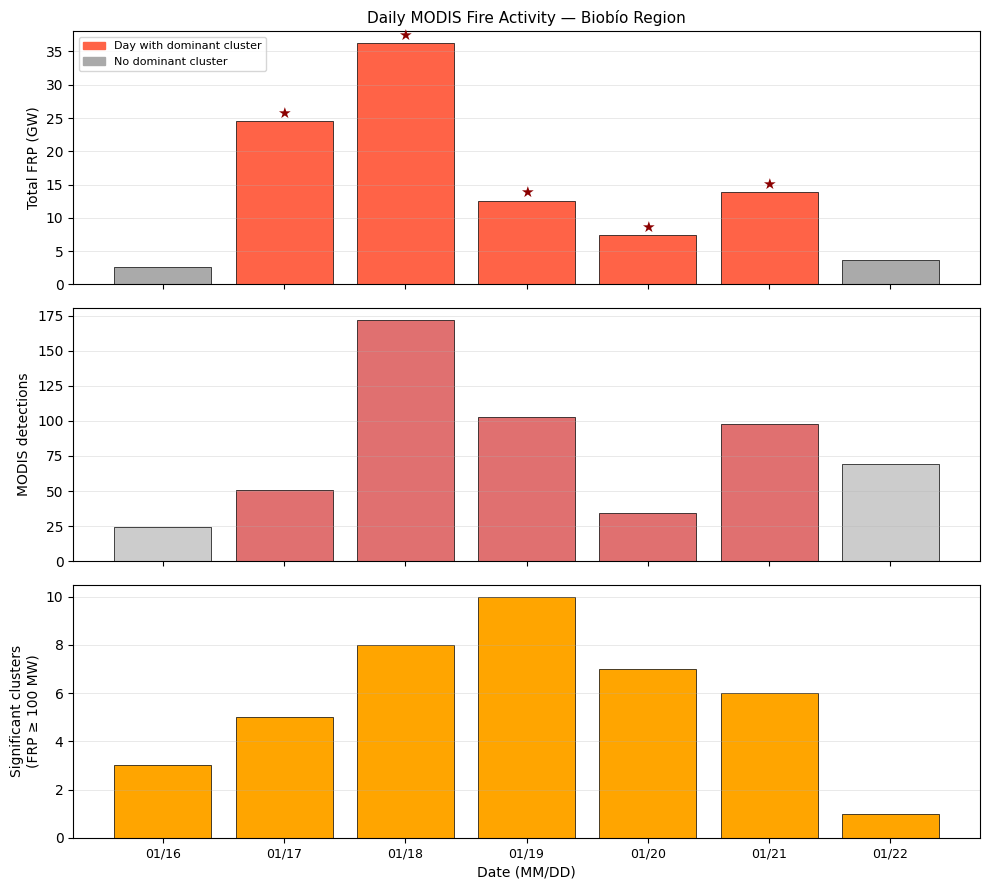

Saved: /Users/maperezc/Downloads/wildfires/outputs/temporal_hotspot/frp_time_series.png


In [9]:
# ---------------------------------------------------------------------------
# FRP time series — total daily FRP, detection count, significant cluster count
# ---------------------------------------------------------------------------

summary_df = pd.DataFrame(summary_rows)

dates      = [pd.Timestamp(r["date"]) for r in summary_rows]
mean_frp_mws = []
for day in all_days:
    day_modis = df[df["acq_date"].dt.normalize() == day]
    mean_frp_mws.append(day_modis["frp"].sum() / 1e3 if len(day_modis) > 0 else 0.0)

n_det_list  = summary_df["n_modis_detections"].tolist()
n_sig_list  = summary_df["n_significant_clusters"].tolist()
date_labels = [d.strftime("%m/%d") for d in dates]
has_dominant = [r["dominant_frp_mw"] is not None for r in summary_rows]
bar_colors   = ["tomato" if hd else "#aaaaaa" for hd in has_dominant]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Panel 1: Total FRP (GW)
ax0 = axes[0]
ax0.bar(date_labels, mean_frp_mws, color=bar_colors, edgecolor="k", linewidth=0.5)
ax0.set_ylabel("Total FRP (GW)", fontsize=10)
ax0.set_title("Daily MODIS Fire Activity — Biobío Region", fontsize=11)
for i, (hd, frp) in enumerate(zip(has_dominant, mean_frp_mws)):
    if hd:
        ax0.text(i, frp + 0.02, "★", ha="center", va="bottom", color="darkred", fontsize=11)
ax0.legend(handles=[
    mpatches.Patch(color="tomato",  label="Day with dominant cluster"),
    mpatches.Patch(color="#aaaaaa", label="No dominant cluster"),
], fontsize=8, loc="upper left")
ax0.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 2: MODIS detection count
ax1 = axes[1]
ax1.bar(date_labels, n_det_list,
        color=["#e07070" if hd else "#cccccc" for hd in has_dominant],
        edgecolor="k", linewidth=0.5)
ax1.set_ylabel("MODIS detections", fontsize=10)
ax1.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 3: Significant cluster count per day
ax2 = axes[2]
ax2.bar(date_labels, n_sig_list, color="orange", edgecolor="k", linewidth=0.5)
ax2.set_ylabel(f"Significant clusters\n(FRP ≥ {SIGNIFICANT_FRP_THRESHOLD_MW:.0f} MW)", fontsize=10)
ax2.set_xlabel("Date (MM/DD)", fontsize=10)
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.tick_params(axis="x", labelsize=9)
ax2.grid(axis="y", linewidth=0.4, alpha=0.5)

fig.tight_layout()
frp_fig_path = FIGURES_DIR / "frp_time_series.png"
fig.savefig(frp_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {frp_fig_path}")


In [10]:
# ---------------------------------------------------------------------------
# Daily statistics summary table
# ---------------------------------------------------------------------------

print("Daily hotspot detection summary")
print("=" * 115)
header = (
    f"{'Date':<12} {'MODIS det':>9} {'Clusters':>8} "
    f"{'AER_AI px':>9} {'Hotspot px':>10} "
    f"{'Dom FRP (MW)':>12} {'Dom lat':>8} {'Dom lon':>9} {'Dist km':>8} "
    f"{'N sig':>6} {'Sig FRP total':>13}"
)
print(header)
print("-" * 115)

for r in summary_rows:
    dom_frp  = f"{r['dominant_frp_mw']:.0f}"       if r["dominant_frp_mw"] is not None  else "—"
    dom_lat  = f"{r['dominant_lat']:.2f}"            if r["dominant_lat"] is not None     else "—"
    dom_lon  = f"{r['dominant_lon']:.2f}"            if r["dominant_lon"] is not None     else "—"
    dom_dist = f"{r['dominant_dist_km']:.0f}"        if r["dominant_dist_km"] is not None else "—"
    sig_tot  = f"{r['significant_clusters_frp_total']:.0f}" if r["n_significant_clusters"] > 0 else "—"

    print(
        f"{str(r['date']):<12} {r['n_modis_detections']:>9} {r['n_clusters']:>8} "
        f"{dom_frp:>12} {dom_lat:>8} {dom_lon:>9} {dom_dist:>8} "
        f"{r['n_significant_clusters']:>6} {sig_tot:>13}"
    )

print("=" * 115)

fire_days = [r["date"] for r in summary_rows]
print(f"\nFire days (hotspot px ≥ 10): {[str(d) for d in fire_days]}")
print(f"Days with dominant cluster:  "
      f"{[str(r['date']) for r in summary_rows if r['dominant_frp_mw'] is not None]}")

# ---------------------------------------------------------------------------
# Significant Cluster Statistics
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("Significant Cluster Statistics")
print("=" * 70)
print(f"  Threshold: FRP ≥ {SIGNIFICANT_FRP_THRESHOLD_MW:.0f} MW (excludes dominant cluster)")
print(f"{'Date':<12} {'Dom FRP (MW)':>12} {'N sig':>6} {'Sig FRP total (MW)':>18} {'Sig FRP max (MW)':>16}")
print("-" * 70)
for r in summary_rows:
    dom  = f"{r['dominant_frp_mw']:.0f}"                    if r["dominant_frp_mw"]             is not None else "—"
    tot  = f"{r['significant_clusters_frp_total']:.0f}"      if r["n_significant_clusters"] > 0  else "—"
    mx   = f"{r['significant_clusters_frp_max']:.0f}"        if r["significant_clusters_frp_max"] is not None else "—"
    print(f"{str(r['date']):<12} {dom:>12} {r['n_significant_clusters']:>6} {tot:>18} {mx:>16}")
print("=" * 70)


Daily hotspot detection summary
Date         MODIS det Clusters AER_AI px Hotspot px Dom FRP (MW)  Dom lat   Dom lon  Dist km  N sig Sig FRP total
-------------------------------------------------------------------------------------------------------------------
2026-01-16          24       16            —        —         —        —      3           820
2026-01-17          51       18          703   -36.78    -72.91       14      5          2589
2026-01-18         172       24          954   -37.55    -72.55       91      8          1403
2026-01-19         103       28          443   -37.49    -72.60       84     10          1491
2026-01-20          34       16          261   -38.60    -72.74      199      7          1702
2026-01-21          98       30          194   -36.78    -72.60       41      6          1292
2026-01-22          69       41            —        —         —        —      1           464

Fire days (hotspot px ≥ 10): ['2026-01-16', '2026-01-17', '2026-01-18', '2026-

In [11]:
# ---------------------------------------------------------------------------
# Save summary CSV (wide format, one row per day)
# ---------------------------------------------------------------------------

summary_df.to_csv(OUTPUT_CSV, index=False, float_format="%.4f")
print(f"Saved: {OUTPUT_CSV}")
print(f"Rows: {len(summary_df)} | Columns: {list(summary_df.columns)}")

# ---------------------------------------------------------------------------
# Save long-format CSV (one row per cluster per day)
# Schema: date, cluster_id, rank_by_frp, n_pixels, mean_frp_mw,
#         centroid_lat, centroid_lon, distance_from_concepcion_km, is_dominant
# The dominant cluster has rank_by_frp = 0 and is_dominant = True.
# Significant (non-dominant) clusters have rank_by_frp >= 1 and is_dominant = False.
# Days with no clusters above the threshold have a sentinel NaN row.
# ---------------------------------------------------------------------------

long_df = pd.DataFrame(long_rows)
long_df.to_csv(OUTPUT_LONG_CSV, index=False, float_format="%.4f")
print(f"\nSaved: {OUTPUT_LONG_CSV}")
print(f"Rows: {len(long_df)} | Columns: {list(long_df.columns)}")
print()
print("First 10 rows of long-format CSV:")
print(long_df.head(10).to_string(index=False))


Saved: /Users/maperezc/Downloads/wildfires/data/daily_dominant_hotspot_summary.csv
Rows: 7 | Columns: ['date', 'mmdd', 'n_modis_detections', 'n_clusters', 'scene_n_valid', 'scene_n_hotspot', 'product', 'dominant_cluster_id', 'dominant_frp_mw', 'dominant_n_detections', 'dominant_lat', 'dominant_lon', 'dominant_dist_km', 'n_significant_clusters', 'significant_clusters_frp_total', 'significant_clusters_frp_max', 'significant_clusters_centroids']

Saved: /Users/maperezc/Downloads/wildfires/data/daily_significant_clusters.csv
Rows: 45 | Columns: ['date', 'cluster_id', 'rank_by_frp', 'n_pixels', 'mean_frp_mw', 'centroid_lat', 'centroid_lon', 'distance_from_concepcion_km', 'is_dominant']

First 10 rows of long-format CSV:
      date  cluster_id  rank_by_frp  n_pixels  mean_frp_mw  centroid_lat  centroid_lon  distance_from_concepcion_km  is_dominant
2026-01-16          14            1         3   410.836667    -13.702715    -55.682447                  3096.667954        False
2026-01-16       

## Limitations and Caveats

### 1. MODIS pixel size and clustering geometry
MODIS fire pixels are 1 km × 1 km at nadir and up to ~2 km × 5 km at high
scan angles near swath edges. The 20 km single-linkage threshold applies to pixel
*centres*, not pixel footprints; adjacent edge pixels can therefore be assigned to
different clusters. This is the Jin et al. (2021) convention and is consistent with
the ~20 km spatial resolution of TROPOMI NO₂ after wind-frame rotation and binning.

### 2. FRP threshold (200 MW) is empirical
The 200 MW minimum FRP for dominant cluster selection is taken from Jin et al. (2021)
Table S1, calibrated on Canadian boreal fires. Chilean temperate forest fires may
have lower instantaneous FRP per unit area (different fuel load, burning conditions).
On low-FRP days, the pipeline selects no dominant cluster and produces no emission
estimate — this is conservative behaviour, not a bug.

### 3. MODIS / TROPOMI temporal mismatch
MODIS Terra overpass over central Chile occurs at ~14:30–15:00 UTC (≈ 11:30–12:00
CLST); TROPOMI overpass at ~16:30 UTC (≈ 13:30 CLST). The 2-hour offset means
active fire pixels are not strictly contemporaneous. Rapidly evolving fires can
shift their centre by 5–20 km in 2 hours, introducing a bias in the EMG rotation
origin. VIIRS (375 m, 14:30 UTC) would reduce temporal mismatch but is not used here.

### 4. 200 km search radius is centred on Concepción
This anchors the search to the Biobío administrative region, which contains the
Jan 2026 fire complex. Fires outside this radius are not detected as dominant clusters
even if they are the largest FRP source in the TROPOMI domain. This is intentional:
the NOₓ EMG pipeline is calibrated for the Concepción fire complex specifically.

### 5. GIF colour resolution
PIL GIF encoding uses a 256-colour palette per frame. The AER_AI scatter with
continuous RdYlBu_r colourmap will be slightly quantised in the GIF output.
Individual per-day PNG figures (150 dpi, full RGB) are the archival quality output.